# 🚗 BMW Sales — Preparación de Datos para Clustering (Aprendizaje No Supervisado)

**Dataset:** `BMW_sales.csv`  
**Objetivo:** Preparar los datos para algoritmos de clustering (K-Means, DBSCAN, etc.)  
**Técnicas de codificación:** Label Encoding vs One-Hot Encoding (comparación)  
**Escalado:** StandardScaler (media=0, desviación estándar=1)

---


## 📦 1. Importación de Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


## 📂 2. Carga de Datos

In [3]:
df = pd.read_csv('../Database/BMW_sales.csv')

print(f"📐 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print()
df.head(10)


📐 Dimensiones: 50000 filas × 10 columnas



,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080
5,5 Series,2017,Middle East,Silver,Diesel,Manual,1.9,171362,42926,1232
6,i8,2022,Europe,White,Diesel,Manual,1.8,196741,55064,7949
7,M5,2014,Asia,Black,Diesel,Automatic,1.6,121156,102778,632
8,X3,2016,South America,White,Diesel,Automatic,1.7,48073,116482,8944
9,i8,2019,Europe,White,Electric,Manual,3.0,35700,96257,4411


## 🔍 3. Exploración Inicial del Dataset

In [4]:
# Tipos de datos y valores nulos
print("=" * 55)
print("TIPOS DE DATOS Y VALORES NULOS")
print("=" * 55)
info_df = pd.DataFrame({
    'Dtype':    df.dtypes,
    'Nulos':    df.isnull().sum(),
    '% Nulos':  (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos':   df.nunique()
})
print(info_df.to_string())


TIPOS DE DATOS Y VALORES NULOS
                  Dtype  Nulos  % Nulos  Únicos
Model            object      0      0.0      11
 Year             int64      0      0.0      15
 Region          object      0      0.0       6
 Color           object      0      0.0       6
 Fuel_Type       object      0      0.0       4
 Transmission    object      0      0.0       2
 Engine_Size_L  float64      0      0.0      36
 Mileage_KM       int64      0      0.0   44347
 Price_USD        int64      0      0.0   38246
 Sales_Volume     int64      0      0.0    9845


In [5]:
# Estadísticas descriptivas de columnas numéricas
print("ESTADÍSTICAS DESCRIPTIVAS — Variables Numéricas")
df.describe().round(2)


ESTADÍSTICAS DESCRIPTIVAS — Variables Numéricas


,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,2017.02,3.25,100307.20,75034.60,5067.51
std,4.32,1.01,57941.51,25998.25,2856.77
min,2010.00,1.50,3.00,30000.00,100.00
25%,2013.00,2.40,50178.00,52434.75,2588.00
50%,2017.00,3.20,100388.50,75011.50,5087.00
75%,2021.00,4.10,150630.25,97628.25,7537.25
max,2024.00,5.00,199996.00,119998.00,9999.00


In [6]:
# Distribución de variables categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Variables categóricas: {cat_cols}\n")

for col in cat_cols:
    print(f"📌 {col}:")
    print(df[col].value_counts().to_string())
    print()


Variables categóricas: ['Model   ', ' Region       ', ' Color ', ' Fuel_Type', ' Transmission']

📌 Model   :
Model   
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413

📌  Region       :
 Region       
Asia             8454
Middle East      8373
North America    8335
Europe           8334
Africa           8253
South America    8251

📌  Color :
 Color 
Red       8463
Silver    8350
Grey      8348
White     8304
Black     8273
Blue      8262

📌  Fuel_Type:
 Fuel_Type
Hybrid       12716
Petrol       12550
Electric     12471
Diesel       12263

📌  Transmission:
 Transmission
Manual          25154
Automatic       24846



## 🧹 4. Limpieza de Datos

In [6]:
df_clean = df.copy()

# 4.1 Eliminar duplicados exactos
antes = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"🗑️  Duplicados eliminados: {antes - len(df_clean)}")

# 4.2 Imputar valores nulos
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        mediana = df_clean[col].median()
        df_clean[col].fillna(mediana, inplace=True)
        print(f"  📊 {col}: imputado con mediana = {mediana:.2f}")

for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f"  🏷️  {col}: imputado con moda = '{moda}'")

print(f"\n✅ Nulos restantes: {df_clean.isnull().sum().sum()}")
print(f"📐 Dimensiones finales: {df_clean.shape}")


🗑️  Duplicados eliminados: 0

✅ Nulos restantes: 0
📐 Dimensiones finales: (50000, 10)


## 📊 5. Análisis de Outliers (Variables Numéricas)

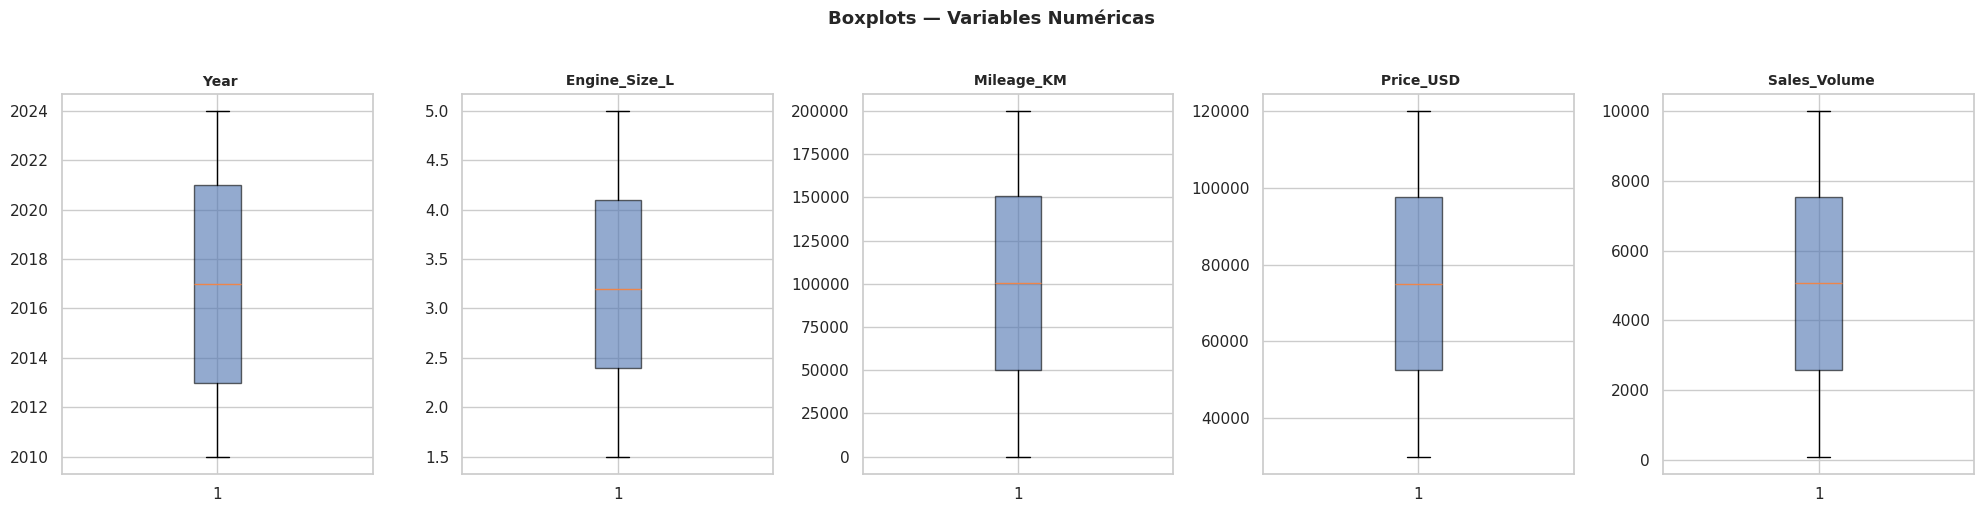

In [7]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))

if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Boxplots — Variables Numéricas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [8]:
# Detección IQR y tratamiento de outliers (winsorizing al 1.5×IQR)
df_no_outliers = df_clean.copy()

print("Outliers detectados y tratados (método IQR):")
for col in num_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)).sum()
    df_no_outliers[col] = df_no_outliers[col].clip(lower, upper)
    print(f"  {col}: {n_out} outliers recortados → [{lower:.1f}, {upper:.1f}]")

print("\n✅ Outliers tratados por winsorizing (no se eliminaron filas)")


Outliers detectados y tratados (método IQR):
   Year: 0 outliers recortados → [2001.0, 2033.0]
   Engine_Size_L: 0 outliers recortados → [-0.1, 6.6]
   Mileage_KM: 0 outliers recortados → [-100500.4, 301308.6]
   Price_USD: 0 outliers recortados → [-15355.5, 165418.5]
   Sales_Volume: 0 outliers recortados → [-4835.9, 14961.1]

✅ Outliers tratados por winsorizing (no se eliminaron filas)


## 🔢 6a. Codificación — Label Encoding

> **Cuándo usarlo:** Cuando el algoritmo de clustering puede interpretar orden implícito o cuando quieres reducir dimensiones.  
> **Ventaja:** Mantiene 1 columna por variable categórica.  
> **Desventaja:** Introduce orden artificial (p.ej. `Rojo=0`, `Azul=1`, `Negro=2`).


In [9]:
df_le = df_no_outliers.copy()
le_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_le[col] = le.fit_transform(df_le[col].astype(str))
    le_encoders[col] = le
    print(f"🏷️  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\n📐 Dimensiones con Label Encoding: {df_le.shape}")
df_le.head()


🏷️  Model   : {'3 Series': np.int64(0), '5 Series': np.int64(1), '7 Series': np.int64(2), 'M3      ': np.int64(3), 'M5      ': np.int64(4), 'X1      ': np.int64(5), 'X3      ': np.int64(6), 'X5      ': np.int64(7), 'X6      ': np.int64(8), 'i3      ': np.int64(9), 'i8      ': np.int64(10)}
🏷️   Region       : {' Africa       ': np.int64(0), ' Asia         ': np.int64(1), ' Europe       ': np.int64(2), ' Middle East  ': np.int64(3), ' North America': np.int64(4), ' South America': np.int64(5)}
🏷️   Color : {' Black ': np.int64(0), ' Blue  ': np.int64(1), ' Grey  ': np.int64(2), ' Red   ': np.int64(3), ' Silver': np.int64(4), ' White ': np.int64(5)}
🏷️   Fuel_Type: {' Diesel   ': np.int64(0), ' Electric ': np.int64(1), ' Hybrid   ': np.int64(2), ' Petrol   ': np.int64(3)}
🏷️   Transmission: {' Automatic   ': np.int64(0), ' Manual      ': np.int64(1)}

📐 Dimensiones con Label Encoding: (50000, 10)


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
0,1,2016,1,3,3,1,3.5,151748,98740,8300
1,10,2013,4,3,2,0,1.6,121671,79219,3428
2,1,2022,4,1,3,0,4.5,10991,113265,6994
3,6,2024,3,1,3,0,1.7,27255,60971,4047
4,2,2020,5,0,0,1,2.1,122131,49898,3080


In [10]:
# Escalar con StandardScaler (Label Encoding)
scaler_le = StandardScaler()
X_le = scaler_le.fit_transform(df_le)
X_le_df = pd.DataFrame(X_le, columns=df_le.columns)

print("✅ StandardScaler aplicado sobre Label Encoding")
print(f"   Media  ≈ 0: {X_le_df.mean().abs().max():.6f}")
print(f"   Std   ≈ 1: {X_le_df.std().max():.6f}")
X_le_df.describe().round(3)


✅ StandardScaler aplicado sobre Label Encoding
   Media  ≈ 0: 0.000000
   Std   ≈ 1: 1.000010


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.573,-1.622,-1.466,-1.470,-1.356,-1.006,-1.731,-1.731,-1.732,-1.739
25%,-0.943,-0.929,-0.879,-0.883,-0.459,-1.006,-0.840,-0.865,-0.869,-0.868
50%,0.001,-0.004,-0.292,0.290,0.439,0.994,-0.047,0.001,-0.001,0.007
75%,0.946,0.921,0.882,0.877,1.336,0.994,0.845,0.869,0.869,0.865
max,1.576,1.615,1.469,1.464,1.336,0.994,1.737,1.721,1.729,1.726


## 🔳 6b. Codificación — One-Hot Encoding

> **Cuándo usarlo:** Cuando las categorías NO tienen orden (colores, regiones, etc.) y el algoritmo es sensible a distancias (K-Means usa distancia Euclidiana).  
> **Ventaja:** No introduce orden artificial.  
> **Desventaja:** Aumenta la dimensionalidad (curse of dimensionality).


In [11]:
df_ohe = df_no_outliers.copy()
df_ohe = pd.get_dummies(df_ohe, columns=cat_cols, drop_first=True)

print(f"📐 Dimensiones originales:       {df_no_outliers.shape}")
print(f"📐 Dimensiones con One-Hot Enc.: {df_ohe.shape}")
print(f"   Columnas nuevas generadas: {df_ohe.shape[1] - df_no_outliers.shape[1] + len(cat_cols)}")
df_ohe.head()


📐 Dimensiones originales:       (50000, 10)
📐 Dimensiones con One-Hot Enc.: (50000, 29)
   Columnas nuevas generadas: 24


,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Model _5 Series,Model _7 Series,Model _M3,Model _M5,Model _X1,...,Region _ South America,Color _ Blue,Color _ Grey,Color _ Red,Color _ Silver,Color _ White,Fuel_Type_ Electric,Fuel_Type_ Hybrid,Fuel_Type_ Petrol,Transmission_ Manual
0,2016,3.5,151748,98740,8300,True,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,2013,1.6,121671,79219,3428,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
2,2022,4.5,10991,113265,6994,True,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
3,2024,1.7,27255,60971,4047,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4,2020,2.1,122131,49898,3080,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True


In [12]:
# Escalar con StandardScaler (One-Hot Encoding)
scaler_ohe = StandardScaler()
X_ohe = scaler_ohe.fit_transform(df_ohe)
X_ohe_df = pd.DataFrame(X_ohe, columns=df_ohe.columns)

print("✅ StandardScaler aplicado sobre One-Hot Encoding")
print(f"   Media  ≈ 0: {X_ohe_df.mean().abs().max():.6f}")
print(f"   Std   ≈ 1: {X_ohe_df.std().max():.6f}")


✅ StandardScaler aplicado sobre One-Hot Encoding
   Media  ≈ 0: 0.000000
   Std   ≈ 1: 1.000010


## ⚖️  7. Comparación: Label Encoding vs One-Hot Encoding

In [ ]:
resumen = pd.DataFrame({
    'Característica': [
        'N° de columnas finales',
        'Orden artificial en categorías',
        'Adecuado para K-Means (distancia Euclidiana)',
        'Adecuado para DBSCAN',
        'Riesgo de alta dimensionalidad',
        'Interpretabilidad'
    ],
    'Label Encoding': [
        df_le.shape[1],
        '⚠️  Sí (puede sesgar)',
        '⚠️  Con precaución',
        '✅ Sí',
        '✅ Bajo',
        '✅ Alta'
    ],
    'One-Hot Encoding': [
        df_ohe.shape[1],
        '✅ No',
        '✅ Recomendado',
        '✅ Sí',
        '⚠️  Alto',
        '⚠️  Media'
    ]
})

resumen.set_index('Característica', inplace=True)
print(resumen.to_string())


In [ ]:
# Visualizar correlaciones — Label Encoding
plt.figure(figsize=(10, 8))
corr_le = pd.DataFrame(X_le, columns=df_le.columns)
mask = np.triu(np.ones_like(corr_le.corr()))
sns.heatmap(corr_le.corr(), mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8})
plt.title('Mapa de Correlación — Label Encoding (escalado)', fontsize=13)
plt.tight_layout()
plt.show()


## 💾 8. Exportar Datasets Listos para Clustering

In [13]:
# Guardar ambas versiones escaladas
pd.DataFrame(X_le, columns=df_le.columns).to_csv('BMW_prep_LabelEncoding.csv', index=False)
pd.DataFrame(X_ohe, columns=df_ohe.columns).to_csv('BMW_prep_OneHotEncoding.csv', index=False)

print("✅ Archivos exportados:")
print("   📄 BMW_prep_LabelEncoding.csv  →", pd.DataFrame(X_le).shape)
print("   📄 BMW_prep_OneHotEncoding.csv →", pd.DataFrame(X_ohe).shape)


✅ Archivos exportados:
   📄 BMW_prep_LabelEncoding.csv  → (50000, 10)
   📄 BMW_prep_OneHotEncoding.csv → (50000, 29)


In [14]:
# Resumen final del pipeline
print("=" * 60)
print("  RESUMEN DEL PIPELINE DE PREPROCESAMIENTO")
print("=" * 60)
print(f"  1. Carga de datos          : {df.shape[0]} filas × {df.shape[1]} cols")
print(f"  2. Duplicados eliminados   : {len(df) - len(df_clean)}")
print(f"  3. Outliers tratados       : IQR winsorizing")
print(f"  4. Escalado                : StandardScaler")
print()
print(f"  Versión A — Label Encoding : {df_le.shape[1]} features")
print(f"  Versión B — One-Hot Encod. : {df_ohe.shape[1]} features")
print()
print("  🎯 Recomendación para K-Means: usar One-Hot Encoding")
print("     (sensible a distancias Euclidianas)")
print("=" * 60)


  RESUMEN DEL PIPELINE DE PREPROCESAMIENTO
  1. Carga de datos          : 50000 filas × 10 cols
  2. Duplicados eliminados   : 0
  3. Outliers tratados       : IQR winsorizing
  4. Escalado                : StandardScaler

  Versión A — Label Encoding : 10 features
  Versión B — One-Hot Encod. : 29 features

  🎯 Recomendación para K-Means: usar One-Hot Encoding
     (sensible a distancias Euclidianas)


## 🚀 9. Próximos Pasos — Algoritmos de Clustering

```python
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# ── K-Means con método del codo ──────────────────────────────
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_ohe)          # usar One-Hot escalado
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, 'o-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

# ── K-Means final ────────────────────────────────────────────
k_optimo = 4           # ← ajustar según el codo
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')
labels = km_final.fit_predict(X_ohe)
score = silhouette_score(X_ohe, labels)
print(f"Silhouette Score: {score:.4f}")

# ── DBSCAN ───────────────────────────────────────────────────
db = DBSCAN(eps=1.5, min_samples=5)
labels_db = db.fit_predict(X_ohe)
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f"DBSCAN encontró {n_clusters} clusters")
```
